<a href="https://colab.research.google.com/github/JamesTan44181/DLI-Group-Assignment/blob/main/Shao_Ern_Individual(Paper%20dataset%EF%BC%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1, Import library and dataset

In [ ]:

# Import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.metrics import Precision, Recall, AUC
from keras.callbacks import EarlyStopping

from google.colab import drive
drive.mount('/content/drive')

df= pd.read_csv('/content/drive/My Drive/Colab Notebooks/Phishing_Legitimate_full.csv')

# Check structure
print(df.head())
print(df.columns)

Mounted at /content/drive
   id  NumDots  SubdomainLevel  PathLevel  UrlLength  NumDash  \
0   1        3               1          5         72        0   
1   2        3               1          3        144        0   
2   3        3               1          2         58        0   
3   4        3               1          6         79        1   
4   5        3               0          4         46        0   

   NumDashInHostname  AtSymbol  TildeSymbol  NumUnderscore  ...  \
0                  0         0            0              0  ...   
1                  0         0            0              2  ...   
2                  0         0            0              0  ...   
3                  0         0            0              0  ...   
4                  0         0            0              0  ...   

   IframeOrFrame  MissingTitle  ImagesOnlyInForm  SubdomainLevelRT  \
0              0             0                 1                 1   
1              0             0          

# 2. Data Preprocessing

In [ ]:

X = df.drop('CLASS_LABEL', axis=1)
y = df['CLASS_LABEL']

# Normalize feature values
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

## 3. Reshape features for LSTM input

In [ ]:
# Reshape to 3D
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

## 4. Model definition: Multilayer Perceptron (MLP) for binary classification

In [ ]:
model = Sequential()
model.add(LSTM(128, input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.3))  # Helps prevent overfitting
model.add(Dense(1, activation='sigmoid'))  # Binary classification

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 5. Compile mode

In [ ]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', Precision(), Recall(), AUC()])

## 6. Training callbacks

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

## 7. Train model

In [ ]:
import time

start = time.time()

history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=64,
                    callbacks=[earlystop],
                    verbose=2)

end = time.time()

print(f"Training time: {end - start:.2f} seconds")

Epoch 1/50
88/88 - 13s - 151ms/step - accuracy: 0.6325 - auc: 0.6586 - loss: 0.6676 - precision: 0.6467 - recall: 0.5678 - val_accuracy: 0.7414 - val_auc: 0.7697 - val_loss: 0.6053 - val_precision: 0.8194 - val_recall: 0.6107
Epoch 2/50
88/88 - 21s - 239ms/step - accuracy: 0.8188 - auc: 0.9037 - loss: 0.3965 - precision: 0.8406 - recall: 0.7821 - val_accuracy: 0.8857 - val_auc: 0.9731 - val_loss: 0.2612 - val_precision: 0.9617 - val_recall: 0.8003
Epoch 3/50
88/88 - 16s - 187ms/step - accuracy: 0.9236 - auc: 0.9773 - loss: 0.1933 - precision: 0.9237 - recall: 0.9217 - val_accuracy: 0.9443 - val_auc: 0.9867 - val_loss: 0.1486 - val_precision: 0.9448 - val_recall: 0.9421
Epoch 4/50
88/88 - 12s - 132ms/step - accuracy: 0.9371 - auc: 0.9843 - loss: 0.1600 - precision: 0.9375 - recall: 0.9354 - val_accuracy: 0.9471 - val_auc: 0.9884 - val_loss: 0.1411 - val_precision: 0.9625 - val_recall: 0.9291
Epoch 5/50
88/88 - 10s - 111ms/step - accuracy: 0.9443 - auc: 0.9857 - loss: 0.1461 - precision:

## 8. Evaluation: Accuracy, Precision, Recall, F1-score, ROC–AUC

In [ ]:
# Predict on test set
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluation
print(classification_report(y_test, y_pred))
print("AUC Score:", roc_auc_score(y_test, y_pred_prob))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1463
           1       1.00      1.00      1.00      1537

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

AUC Score: 0.9999871032641638
Confusion Matrix:
[[1462    1]
 [   4 1533]]


## 9. Visualizations: Confusion matrix, ROC curve, (optional) learning curve

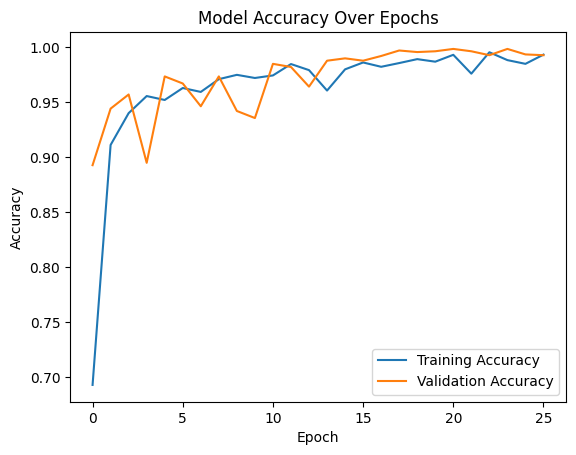

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()